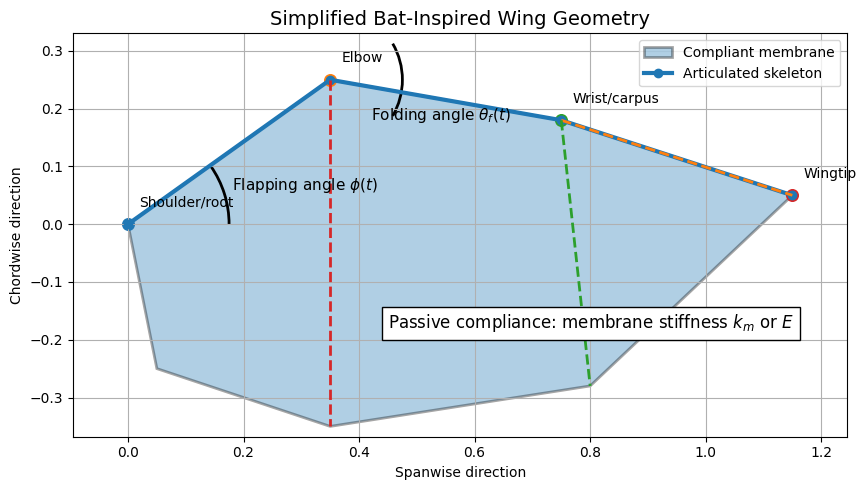

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Arc

# ============================================================
# Bat-inspired wing geometry schematic
# ============================================================

# Joint locations in 2D top view
shoulder = np.array([0.0, 0.0])
elbow    = np.array([0.35, 0.25])
wrist    = np.array([0.75, 0.18])
wingtip  = np.array([1.15, 0.05])

# Trailing edge points
body_trailing = np.array([0.05, -0.25])
inner_trailing = np.array([0.35, -0.35])
outer_trailing = np.array([0.80, -0.28])
tip_trailing = wingtip

# Wing membrane outline
membrane_points = np.array([
    shoulder,
    elbow,
    wrist,
    wingtip,
    outer_trailing,
    inner_trailing,
    body_trailing
])

# Finger-like support bones
digit_3 = np.array([wrist, wingtip])
digit_4 = np.array([wrist, outer_trailing])
digit_5 = np.array([elbow, inner_trailing])

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

# Flexible membrane
wing_patch = Polygon(
    membrane_points,
    closed=True,
    alpha=0.35,
    edgecolor="black",
    linewidth=2,
    label="Compliant membrane"
)
ax.add_patch(wing_patch)

# Leading edge skeleton
leading_edge = np.array([shoulder, elbow, wrist, wingtip])
ax.plot(
    leading_edge[:, 0],
    leading_edge[:, 1],
    marker="o",
    linewidth=3,
    label="Articulated skeleton"
)

# Finger-like bat wing supports
for digit in [digit_3, digit_4, digit_5]:
    ax.plot(
        digit[:, 0],
        digit[:, 1],
        linestyle="--",
        linewidth=2
    )

# Label points
points = {
    "Shoulder/root": shoulder,
    "Elbow": elbow,
    "Wrist/carpus": wrist,
    "Wingtip": wingtip
}

for label, point in points.items():
    ax.scatter(point[0], point[1], s=70)
    ax.text(point[0] + 0.02, point[1] + 0.03, label, fontsize=10)

# Flapping angle arc near shoulder
arc1 = Arc(
    shoulder,
    width=0.35,
    height=0.35,
    angle=0,
    theta1=0,
    theta2=35,
    linewidth=2
)
ax.add_patch(arc1)
ax.text(0.18, 0.06, r"Flapping angle $\phi(t)$", fontsize=11)

# Folding angle arc near elbow
arc2 = Arc(
    elbow,
    width=0.25,
    height=0.25,
    angle=0,
    theta1=-30,
    theta2=30,
    linewidth=2
)
ax.add_patch(arc2)
ax.text(0.42, 0.18, r"Folding angle $\theta_f(t)$", fontsize=11)

# Membrane stiffness label
ax.text(
    0.45,
    -0.18,
    r"Passive compliance: membrane stiffness $k_m$ or $E$",
    fontsize=12,
    bbox=dict(facecolor="white", edgecolor="black")
)

# Formatting
ax.set_title("Simplified Bat-Inspired Wing Geometry", fontsize=14)
ax.set_xlabel("Spanwise direction")
ax.set_ylabel("Chordwise direction")
ax.axis("equal")
ax.grid(True)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()